# Peak Demand & Load Variance Analysis

**Objective:** Quantify the impact of two demand-response policies on system-level load:
- **Tempo tariff** (`tempo_shifted_profile.csv`)
- **TOU-2 tariff** (`tou_shifted_profile2.zip`)

relative to the **no-policy baseline** (`control_profile.csv`).

Three analysis sections:
1. **Coincident Peak Demand Reduction** — mean & distributional percentiles (kW and % of baseline)
2. **Load Variance** — within-day and across-day; maximum hour-to-hour load slope
3. **Visualizations** throughout for data exploration and results illustration

---
**Data structure:**  
Each row = one household (`hid`) on one `date`.  
Columns `1`–`24` = average power demand (kW) in each of the 24 hours of the day.  
Summing across all households gives the **aggregate system load** in kW for each hour.

## 0. Setup & Data Loading

In [1]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
POLICY_COLORS = {
    "Control (Baseline)": "#2c7bb6",
    "Tempo Tariff":        "#d7191c",
    "TOU-2 Tariff":        "#1a9641",
}
HOUR_LABELS = [str(h) for h in range(1, 25)]

DATA_DIR = "data/"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ── Load raw CSVs ─────────────────────────────────────────────────────────────
ctrl  = pd.read_csv(DATA_DIR + "control_profile.csv")
tempo = pd.read_csv(DATA_DIR + "tempo_shifted_profile.csv")

with zipfile.ZipFile(DATA_DIR + "tou_shifted_profile2.zip") as z:
    with z.open("tou_shifted_profile2.csv") as f:
        tou = pd.read_csv(f)

profiles = {
    "Control (Baseline)": ctrl,
    "Tempo Tariff":        tempo,
    "TOU-2 Tariff":        tou,
}

for name, df in profiles.items():
    print(f"{name:25s}  shape={df.shape}  "
          f"dates={df['date'].nunique()}  "
          f"households={df['hid'].nunique()}")

Control (Baseline)         shape=(197365, 29)  dates=7  households=28195
Tempo Tariff               shape=(197365, 29)  dates=7  households=28195
TOU-2 Tariff               shape=(197365, 29)  dates=7  households=28195


### 0.1 Compute Aggregate System Load

For each profile, sum the hourly readings across all households within each day to get the **system-level load curve** (kW per hour, per day).

In [3]:
def aggregate_system_load(df: pd.DataFrame) -> pd.DataFrame:
    """Sum household loads → system hourly load (kW) grouped by date."""
    return (
        df.groupby("date")[HOUR_LABELS]
          .sum()
          .sort_index()
          .rename_axis("date")
    )

sys_loads = {name: aggregate_system_load(df) for name, df in profiles.items()}

# Preview
print("Control system load (kW) — first 3 days:")
display(sys_loads["Control (Baseline)"].round(1).head(3))

Control system load (kW) — first 3 days:


,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
date,,,,,,,,,,,,,,,,,,,,,
2014-07-01,7772.5,5776.8,5302.2,5557.8,7758.9,9624.7,14692.0,14707.3,11248.9,10274.0,...,8312.7,9051.1,9711.1,9819.2,11189.5,15279.0,17555.4,18194.0,16323.0,5960.3
2014-07-02,9279.6,7340.5,6905.0,7168.4,9328.4,11960.6,16706.6,17291.9,13979.6,13233.1,...,13047.1,13586.6,14360.6,14610.9,15406.0,19125.1,20917.0,21403.4,19040.5,8656.3
2014-07-03,11042.5,8981.0,8443.2,8680.0,10839.9,13299.7,17565.4,18281.4,14411.4,13437.1,...,12024.0,12603.1,13192.0,13384.1,15791.5,18182.8,20138.4,20268.1,17723.5,7228.2


### 0.2 Exploratory Visualization — Daily System Load Curves

Plot the average hourly load profile across all days for each scenario to get an initial sense of how demand-response shifts load.

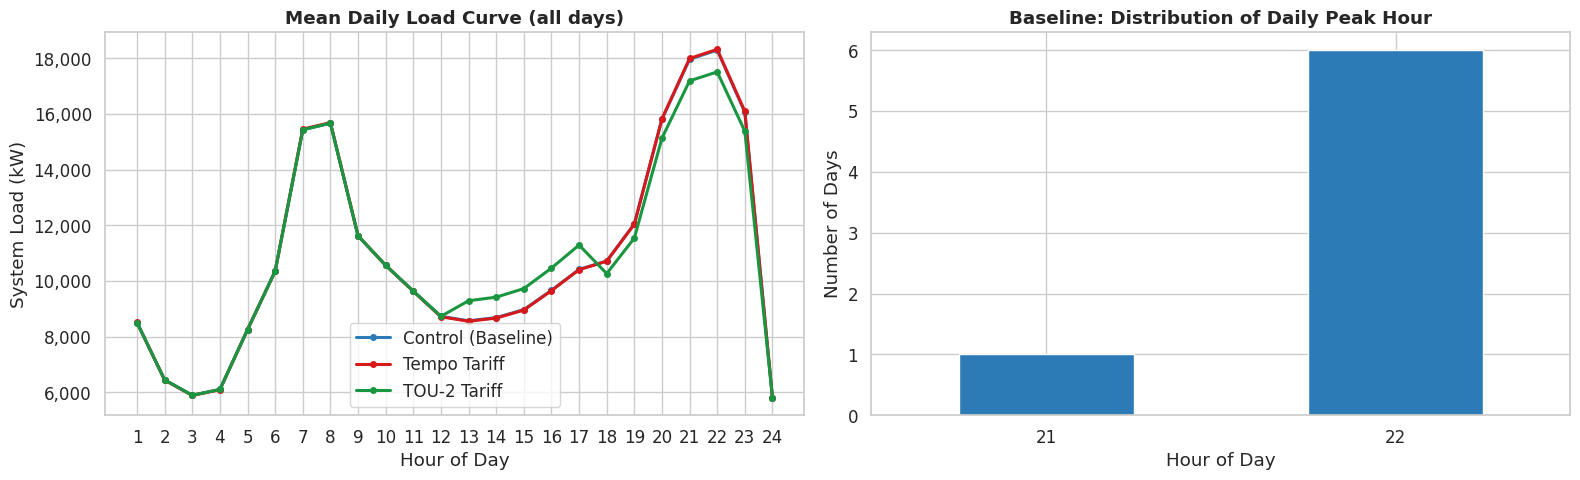

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: average daily curve per policy ─────────────────────────────────────
ax = axes[0]
for name, sl in sys_loads.items():
    mean_curve = sl.mean()  # average across days
    ax.plot(range(1, 25), mean_curve.values,
            color=POLICY_COLORS[name], lw=2.2, label=name, marker="o", ms=4)

ax.set_title("Mean Daily Load Curve (all days)", fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("System Load (kW)")
ax.set_xticks(range(1, 25))
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Right: each day's peak hour distribution (control) ───────────────────────
ax2 = axes[1]
ctrl_peaks_hour = sys_loads["Control (Baseline)"].idxmax(axis=1).astype(int)
ctrl_peaks_hour.value_counts().sort_index().plot(
    kind="bar", ax=ax2, color=POLICY_COLORS["Control (Baseline)"], edgecolor="white")
ax2.set_title("Baseline: Distribution of Daily Peak Hour", fontweight="bold")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Number of Days")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("output/fig1_mean_load_curves.png", dpi=150, bbox_inches="tight")
plt.show()

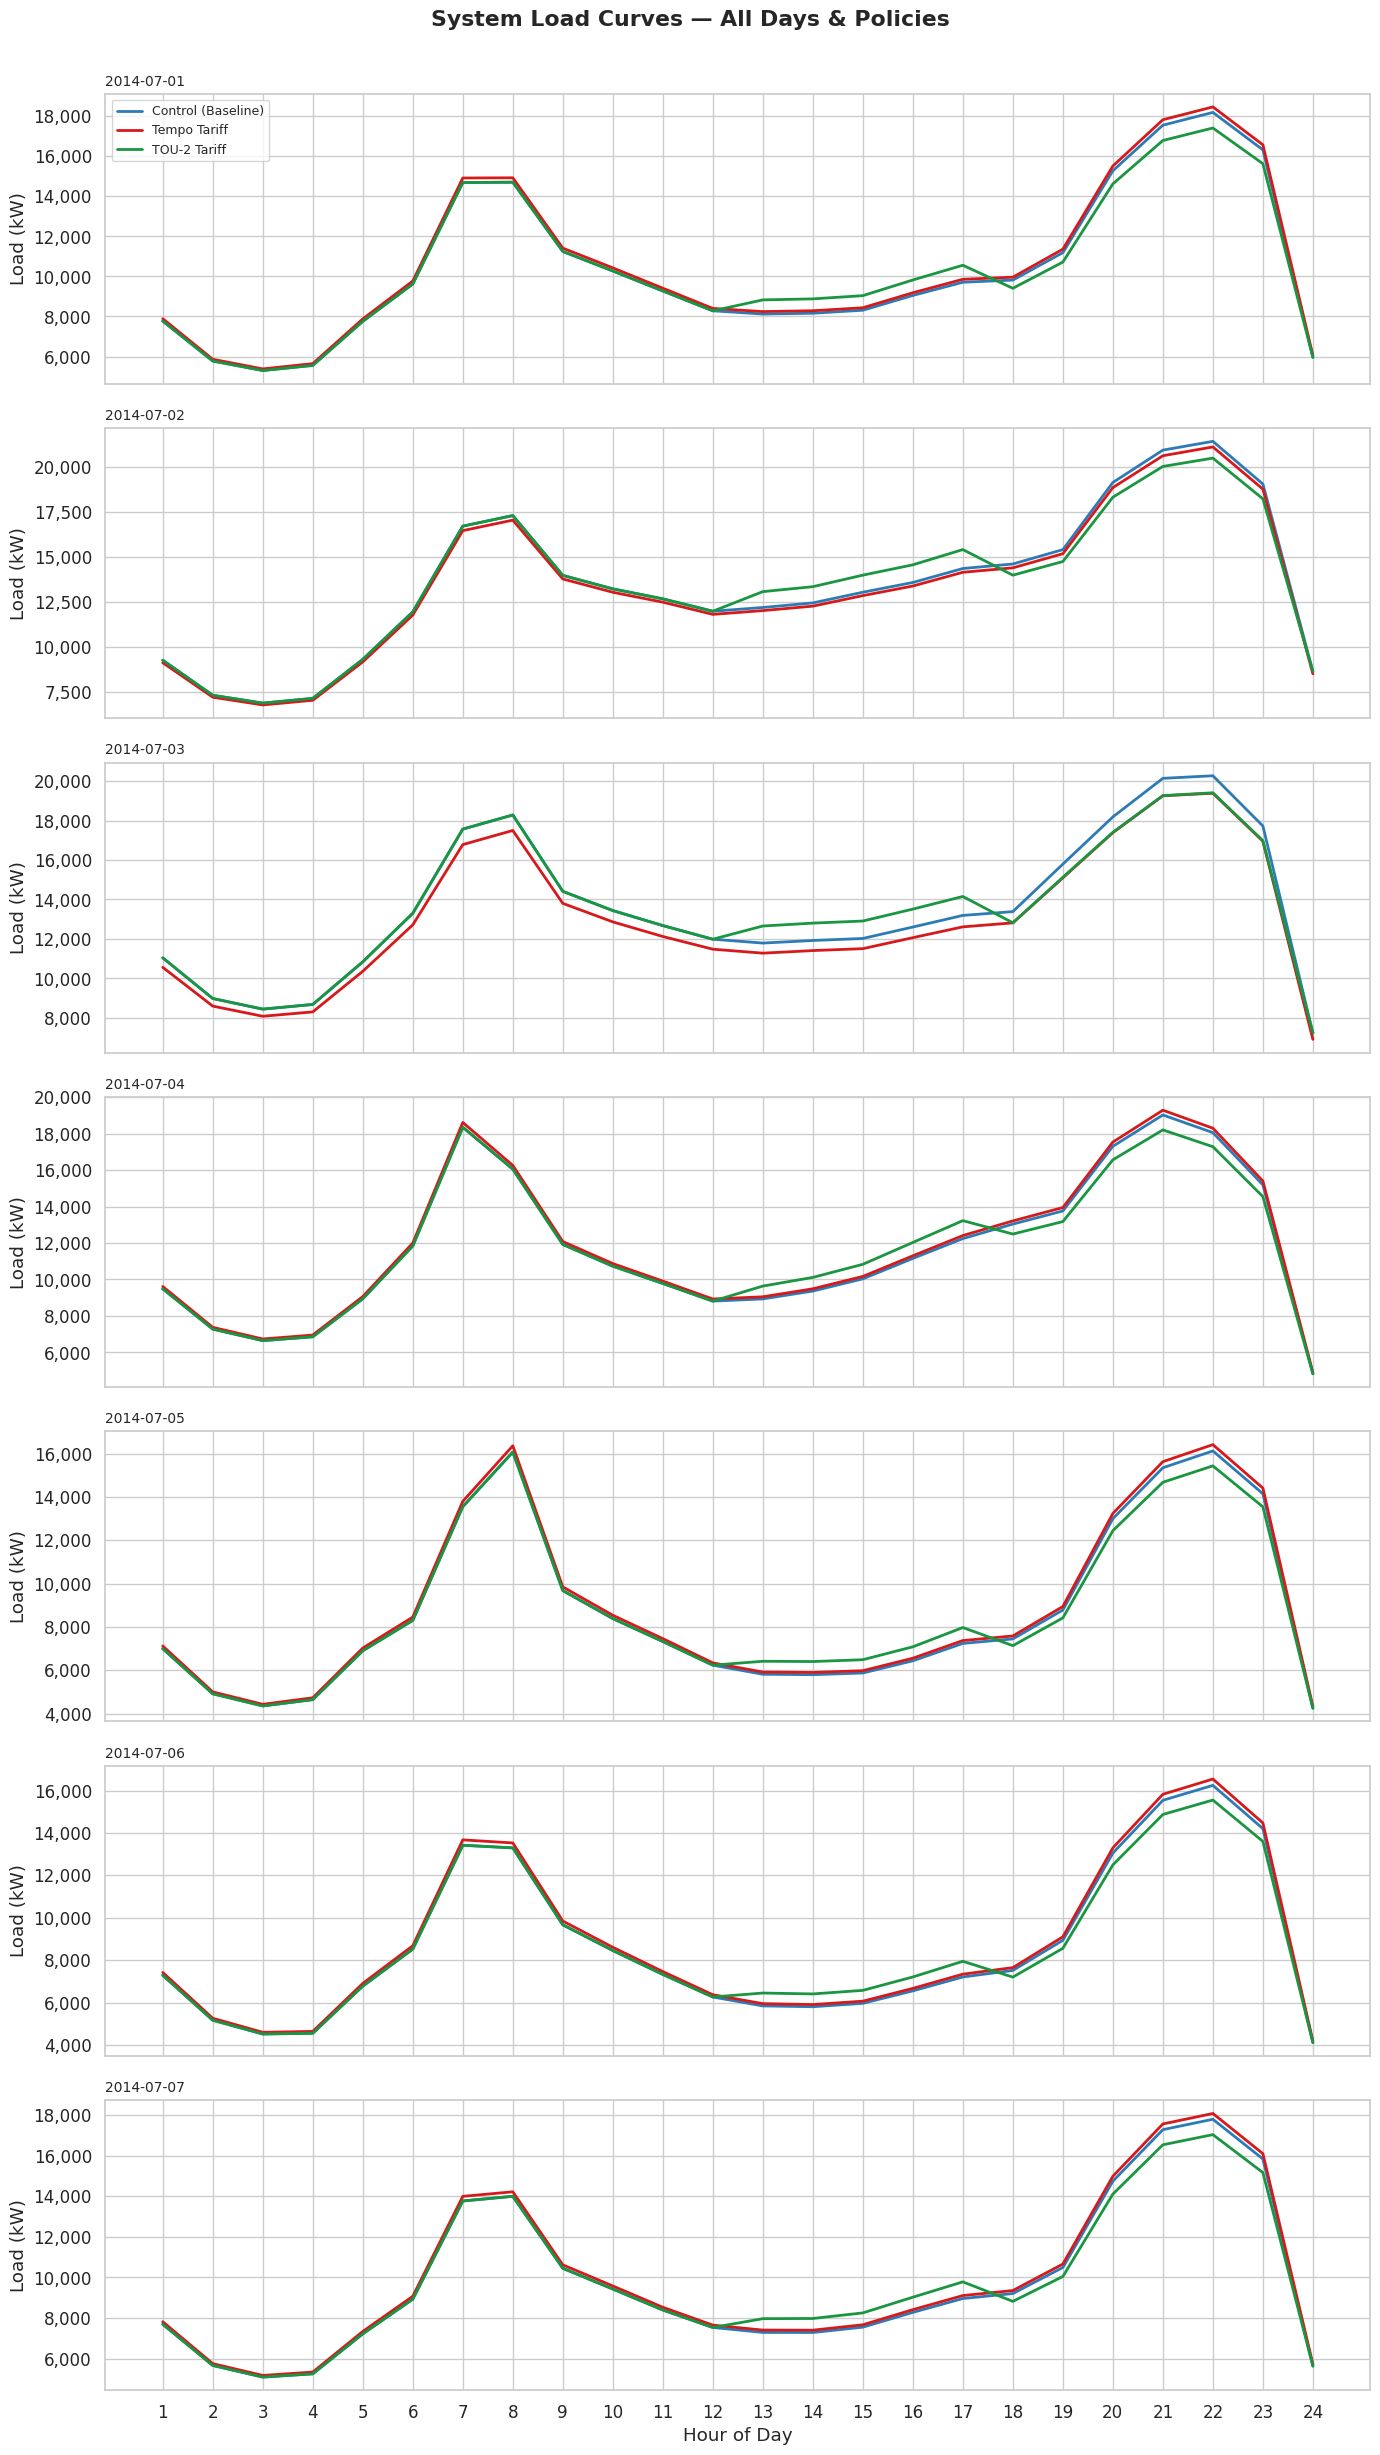

In [5]:
# ── All individual days, all policies (faceted) ───────────────────────────────
dates = sys_loads["Control (Baseline)"].index.tolist()
n_days = len(dates)

fig, axes = plt.subplots(n_days, 1, figsize=(14, 3.5 * n_days), sharex=True)

for i, date in enumerate(dates):
    ax = axes[i]
    for name, sl in sys_loads.items():
        ax.plot(range(1, 25), sl.loc[date].values,
                color=POLICY_COLORS[name], lw=2, label=name if i == 0 else None)
    ax.set_title(f"{date}", fontsize=10, loc="left")
    ax.set_ylabel("Load (kW)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.set_xticks(range(1, 25))

axes[0].legend(loc="upper left", fontsize=9)
axes[-1].set_xlabel("Hour of Day")
fig.suptitle("System Load Curves — All Days & Policies", fontweight="bold", y=1.002)
plt.tight_layout()
plt.savefig("output/fig2_daily_load_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 1. Coincident Peak Demand Reduction

The **coincident peak** is the single highest aggregate system load observed during each day.

For each policy we compute:
- **Reduction (kW)** = baseline peak − policy peak  (positive = reduction)
- **Reduction (%)** = reduction / baseline peak × 100

We then summarize with mean, standard deviation, and key percentiles across the 7-day simulation period.

Daily coincident peak demand (kW):


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
date,,,
2014-07-01,18194.0,18468.1,17415.2
2014-07-02,21403.4,21094.1,20475.1
2014-07-03,20268.1,19382.0,19406.1
2014-07-04,19020.4,19282.1,18348.3
2014-07-05,16130.1,16421.1,16077.6
2014-07-06,16242.1,16539.9,15549.8
2014-07-07,17785.8,18070.5,17029.4


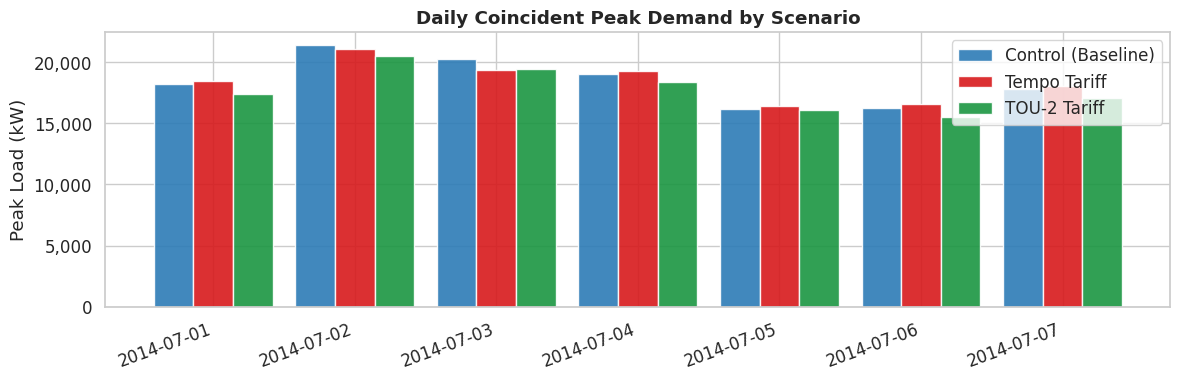

In [6]:
# ── Daily coincident peak per scenario ───────────────────────────────────────
daily_peaks = pd.DataFrame({
    name: sl.max(axis=1) for name, sl in sys_loads.items()
})

print("Daily coincident peak demand (kW):")
display(daily_peaks.round(1))

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(n_days)
width = 0.28
for j, (name, col) in enumerate(daily_peaks.items()):
    ax.bar(x + (j - 1) * width, col.values, width,
           color=POLICY_COLORS[name], label=name, edgecolor="white", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(dates, rotation=20, ha="right")
ax.set_ylabel("Peak Load (kW)")
ax.set_title("Daily Coincident Peak Demand by Scenario", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig("output/fig3_daily_peaks.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ── Peak reductions relative to control ──────────────────────────────────────
baseline_peak = daily_peaks["Control (Baseline)"]

reductions_kw  = pd.DataFrame()
reductions_pct = pd.DataFrame()

for policy in ["Tempo Tariff", "TOU-2 Tariff"]:
    reductions_kw[policy]  = baseline_peak - daily_peaks[policy]
    reductions_pct[policy] = (baseline_peak - daily_peaks[policy]) / baseline_peak * 100

print("Peak reductions (kW):")
display(reductions_kw.round(2))
print("\nPeak reductions (%):")
display(reductions_pct.round(3))

Peak reductions (kW):


,Tempo Tariff,TOU-2 Tariff
date,,
2014-07-01,-274.04,778.82
2014-07-02,309.24,928.26
2014-07-03,886.16,861.99
2014-07-04,-261.72,672.04
2014-07-05,-291.00,52.47
2014-07-06,-297.81,692.28
2014-07-07,-284.77,756.38



Peak reductions (%):


,Tempo Tariff,TOU-2 Tariff
date,,
2014-07-01,-1.506,4.281
2014-07-02,1.445,4.337
2014-07-03,4.372,4.253
2014-07-04,-1.376,3.533
2014-07-05,-1.804,0.325
2014-07-06,-1.834,4.262
2014-07-07,-1.601,4.253


In [8]:
# ── Summary statistics: mean + percentiles ────────────────────────────────────
PERCENTILES = [10, 25, 50, 75, 90]

def summary_table(df: pd.DataFrame, label: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        series = df[col]
        row = {
            "Policy": col,
            "Mean": series.mean(),
            "Std": series.std(ddof=1),
        }
        for p in PERCENTILES:
            row[f"P{p}"] = series.quantile(p / 100)
        rows.append(row)
    out = pd.DataFrame(rows).set_index("Policy")
    out.index.name = f"Reduction ({label})"
    return out

summary_kw  = summary_table(reductions_kw,  "kW")
summary_pct = summary_table(reductions_pct, "%")

print("=" * 72)
print("COINCIDENT PEAK REDUCTION — Summary Statistics")
print("=" * 72)
print("\n[A] Absolute reduction (kW):")
display(summary_kw.round(2))
print("\n[B] Relative reduction (% of baseline peak):")
display(summary_pct.round(3))

COINCIDENT PEAK REDUCTION — Summary Statistics

[A] Absolute reduction (kW):


,Mean,Std,P10,P25,P50,P75,P90
Reduction (kW),,,,,,,
Tempo Tariff,-30.56,460.51,-293.73,-287.89,-274.04,23.76,540.0
TOU-2 Tariff,677.46,289.92,424.21,682.16,756.38,820.41,888.5



[B] Relative reduction (% of baseline peak):


,Mean,Std,P10,P25,P50,P75,P90
Reduction (%),,,,,,,
Tempo Tariff,-0.329,2.373,-1.816,-1.703,-1.506,0.034,2.616
TOU-2 Tariff,3.606,1.473,2.250,3.893,4.253,4.271,4.303


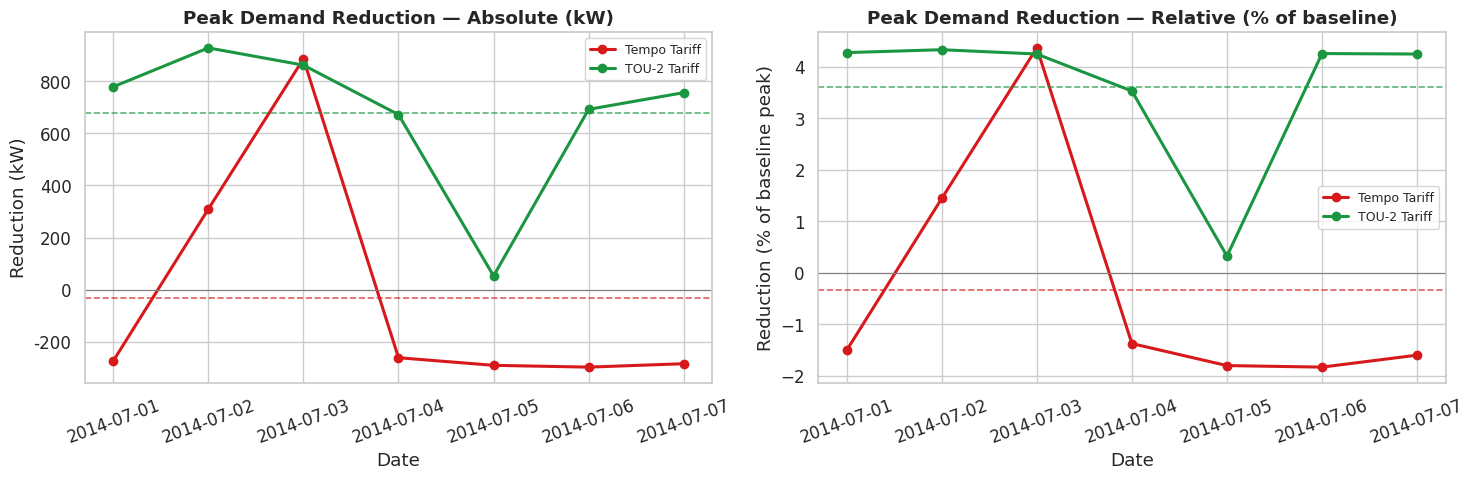

In [9]:
# ── Visualization: daily reductions + percentile bands ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, df, unit, ylabel, title in zip(
    axes,
    [reductions_kw, reductions_pct],
    ["kW", "%"],
    ["Reduction (kW)", "Reduction (% of baseline peak)"],
    ["Peak Demand Reduction — Absolute (kW)",
     "Peak Demand Reduction — Relative (% of baseline)"],
):
    for policy in df.columns:
        color = POLICY_COLORS[policy]
        vals  = df[policy].values
        ax.plot(dates, vals, color=color, lw=2.2, marker="o", ms=6, label=policy)
        ax.axhline(vals.mean(), color=color, lw=1.2, ls="--", alpha=0.7)

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=9)
    ax.axhline(0, color="grey", lw=0.8)
    if unit == "kW":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("output/fig4_peak_reductions.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_4023/3954127485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="Policy", y="Reduction",
/tmp/ipykernel_4023/3954127485.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_data, x="Policy", y="Reduction",
/tmp/ipykernel_4023/3954127485.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="Policy", y="Reduction",
/tmp/ipykernel_4023/3954127485.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

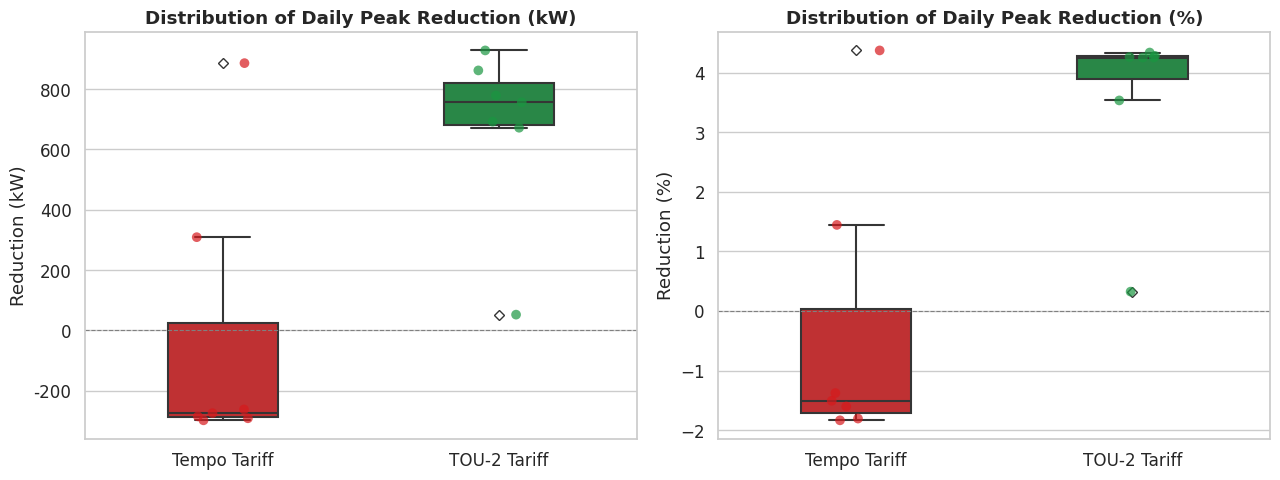


Percentile breakdown (kW):


,Tempo Tariff,TOU-2 Tariff
count,7.00,7.00
mean,-30.56,677.46
std,460.51,289.92
min,-297.81,52.47
10%,-293.73,424.21
25%,-287.89,682.16
50%,-274.04,756.38
75%,23.76,820.41
90%,540.00,888.50
max,886.16,928.26



Percentile breakdown (%):


,Tempo Tariff,TOU-2 Tariff
count,7.000,7.000
mean,-0.329,3.606
std,2.373,1.473
min,-1.834,0.325
10%,-1.816,2.250
25%,-1.703,3.893
50%,-1.506,4.253
75%,0.034,4.271
90%,2.616,4.303
max,4.372,4.337


In [10]:
# ── Box plots — distributional spread across the 7 days ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, unit in zip(axes, [reductions_kw, reductions_pct], ["kW", "%"]):
    plot_data = df.melt(var_name="Policy", value_name="Reduction")
    palette   = {p: POLICY_COLORS[p] for p in df.columns}
    sns.boxplot(data=plot_data, x="Policy", y="Reduction",
                palette=palette, width=0.4, linewidth=1.5,
                flierprops=dict(marker="D", ms=5), ax=ax)
    sns.stripplot(data=plot_data, x="Policy", y="Reduction",
                  palette=palette, size=7, jitter=True, ax=ax, alpha=0.7)
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(f"Distribution of Daily Peak Reduction ({unit})", fontweight="bold")
    ax.set_ylabel(f"Reduction ({unit})")
    ax.set_xlabel("")
    if unit == "kW":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("output/fig5_reduction_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPercentile breakdown (kW):")
display(reductions_kw.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2))
print("\nPercentile breakdown (%):")
display(reductions_pct.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))

---
## 2. Hourly Load Variance & Maximum Slope

### 2a. Within-Day Variance
For each day, compute the **variance of the 24 hourly system loads**.  
This measures how "peaky" the load profile is within a given day — a lower within-day variance suggests a flatter, more uniform load.

### 2b. Across-Day Variance
For each hour slot (1–24), compute the **variance of system load across the 7 days**.  
This measures how consistent that hour's load is from day to day.

### 2c. Maximum Slope
For each day, compute the maximum absolute hour-to-hour change in system load:  
$$\text{MaxSlope}_d = \max_{h \in \{2,...,24\}} \left| L_{d,h} - L_{d,h-1} \right|$$  
A high maximum slope indicates sudden large ramps — costly for grid operators.

In [11]:
# ── Within-day variance ───────────────────────────────────────────────────────
within_day_var = pd.DataFrame({
    name: sl.var(axis=1, ddof=1) for name, sl in sys_loads.items()
})

print("Within-day variance of hourly system load (kW²):")
display(within_day_var.round(1))
print("\nSummary (across days):")
display(within_day_var.describe().round(1))

Within-day variance of hourly system load (kW²):


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
date,,,
2014-07-01,14651179.4,15108582.9,12681438.8
2014-07-02,17339293.8,16829671.6,15385700.3
2014-07-03,13404889.6,12242552.2,11540005.7
2014-07-04,15835913.9,16274643.3,14005791.5
2014-07-05,14943868.8,15497863.2,13142795.0
2014-07-06,13514240.6,14024371.3,11692250.5
2014-07-07,14418555.7,14897572.4,12401979.9



Summary (across days):


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
count,7.0,7.0,7.0
mean,14872563.1,14982179.6,12978565.9
std,1370652.5,1516339.3,1355314.1
min,13404889.6,12242552.2,11540005.7
25%,13966398.1,14460971.8,12047115.2
50%,14651179.4,15108582.9,12681438.8
75%,15389891.4,15886253.2,13574293.3
max,17339293.8,16829671.6,15385700.3


In [12]:
# ── Across-day variance ───────────────────────────────────────────────────────
across_day_var = pd.DataFrame({
    name: sl.var(axis=0, ddof=1) for name, sl in sys_loads.items()
})
across_day_var.index = [int(h) for h in across_day_var.index]
across_day_var.index.name = "Hour"

print("Across-day variance of system load by hour (kW²):")
display(across_day_var.round(1))
print("\nMean across-day variance (over all 24 hours):")
display(across_day_var.mean().round(1).rename("Mean across-day var (kW²)"))

Across-day variance of system load by hour (kW²):


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
Hour,,,
1,2154935.7,1631476.8,2154935.7
2,2154457.6,1732558.8,2154457.6
3,2218978.3,1817354.1,2218978.3
4,2309562.5,1878310.7,2309562.5
5,2269479.2,1708532.7,2269479.2
6,3925744.2,3113536.4,3925744.2
7,4261934.7,3508192.3,4261934.7
8,3189304.2,2214201.5,3189304.2
9,3750846.9,2825156.3,3750846.9



Mean across-day variance (over all 24 hours):


Control (Baseline)    4901189.6
Tempo Tariff          4037007.1
TOU-2 Tariff          4921806.7
Name: Mean across-day var (kW²), dtype: float64

In [13]:
# ── Maximum slope (kW/h) ──────────────────────────────────────────────────────
def max_slope(sl: pd.DataFrame) -> pd.Series:
    """Max absolute hour-to-hour change in system load, per day."""
    diffs = sl.diff(axis=1).abs()  # |L[h] - L[h-1]|
    return diffs.max(axis=1)

max_slopes = pd.DataFrame({
    name: max_slope(sl) for name, sl in sys_loads.items()
})

print("Maximum hour-to-hour load slope (kW/h):")
display(max_slopes.round(1))
print("\nSummary:")
display(max_slopes.describe().round(1))

Maximum hour-to-hour load slope (kW/h):


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
date,,,
2014-07-01,10362.7,10525.6,9671.0
2014-07-02,10384.2,10227.6,9562.6
2014-07-03,10495.3,10039.4,9749.4
2014-07-04,10359.1,10503.3,9712.6
2014-07-05,9900.1,10085.8,9296.0
2014-07-06,10089.0,10282.2,9485.0
2014-07-07,10194.0,10364.6,9523.7



Summary:


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
count,7.0,7.0,7.0
mean,10254.9,10289.8,9571.5
std,205.8,189.3,156.6
min,9900.1,10039.4,9296.0
25%,10141.5,10156.7,9504.3
50%,10359.1,10282.2,9562.6
75%,10373.5,10433.9,9691.8
max,10495.3,10525.6,9749.4


In [14]:
# ── Also record the hour at which the max slope occurs ───────────────────────
def max_slope_hour(sl: pd.DataFrame) -> pd.Series:
    """Hour (2–24) at which the maximum slope occurs."""
    diffs = sl.diff(axis=1).abs()
    return diffs.idxmax(axis=1).astype(int)

max_slope_hours = pd.DataFrame({
    name: max_slope_hour(sl) for name, sl in sys_loads.items()
})
print("Hour at which maximum slope occurs:")
display(max_slope_hours)

Hour at which maximum slope occurs:


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
date,,,
2014-07-01,24,24,24
2014-07-02,24,24,24
2014-07-03,24,24,24
2014-07-04,24,24,24
2014-07-05,24,24,24
2014-07-06,24,24,24
2014-07-07,24,24,24


In [15]:
# ── Compile comprehensive variance & slope summary ────────────────────────────
def variance_summary(name: str) -> dict:
    wdv = within_day_var[name]
    adv = across_day_var[name]
    ms  = max_slopes[name]
    return {
        "Policy": name,
        "Within-Day Var — Mean (kW²)":  wdv.mean(),
        "Within-Day Var — Max (kW²)":   wdv.max(),
        "Across-Day Var — Mean (kW²)":  adv.mean(),
        "Across-Day Var — Max (kW²)":   adv.max(),
        "Max Slope — Mean (kW/h)":      ms.mean(),
        "Max Slope — Max (kW/h)":       ms.max(),
    }

var_summary_df = pd.DataFrame([
    variance_summary(name) for name in profiles.keys()
]).set_index("Policy")

print("=" * 72)
print("VARIANCE & MAXIMUM SLOPE SUMMARY")
print("=" * 72)
display(var_summary_df.round(1))

VARIANCE & MAXIMUM SLOPE SUMMARY


,Within-Day Var — Mean (kW²),Within-Day Var — Max (kW²),Across-Day Var — Mean (kW²),Across-Day Var — Max (kW²),Max Slope — Mean (kW/h),Max Slope — Max (kW/h)
Policy,,,,,,
Control (Baseline),14872563.1,17339293.8,4901189.6,8611882.7,10254.9,10495.3
Tempo Tariff,14982179.6,16829671.6,4037007.1,7628336.0,10289.8,10525.6
TOU-2 Tariff,12978565.9,15385700.3,4921806.7,8972143.5,9571.5,9749.4


### 2d. Visualizations — Variance & Slope

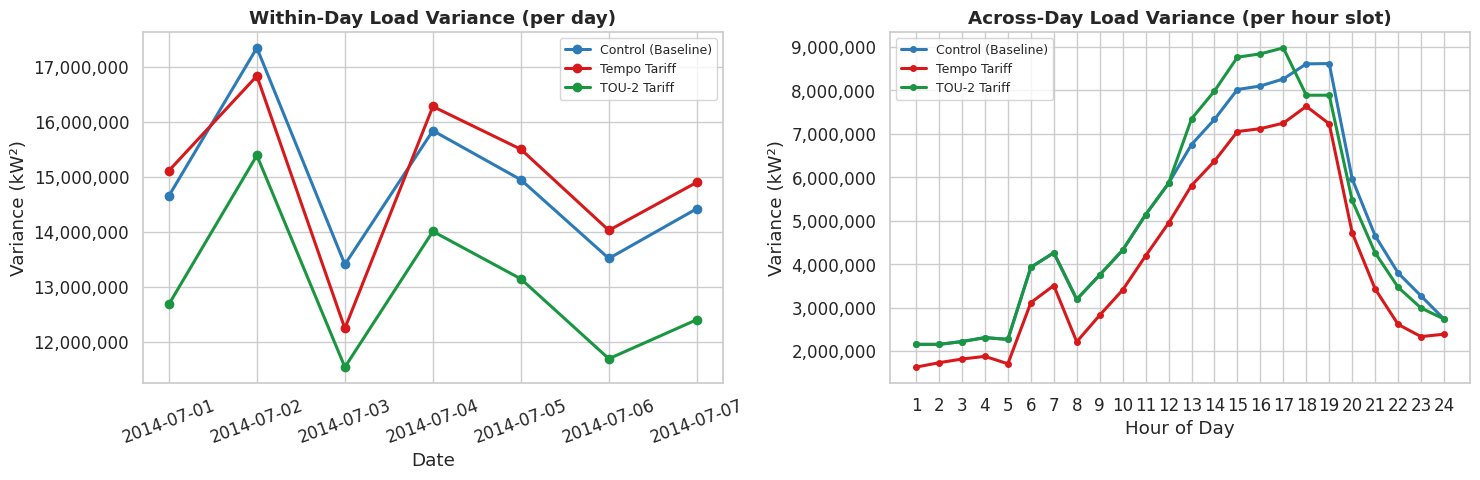

In [16]:
# ── Within-day variance: time series ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for name in profiles.keys():
    ax.plot(dates, within_day_var[name].values,
            color=POLICY_COLORS[name], lw=2.2, marker="o", ms=6, label=name)
ax.set_title("Within-Day Load Variance (per day)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Variance (kW²)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Across-day variance: line over hours ──────────────────────────────────────
ax2 = axes[1]
for name in profiles.keys():
    ax2.plot(range(1, 25), across_day_var[name].values,
             color=POLICY_COLORS[name], lw=2.2, marker="o", ms=4, label=name)
ax2.set_title("Across-Day Load Variance (per hour slot)", fontweight="bold")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Variance (kW²)")
ax2.set_xticks(range(1, 25))
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("output/fig6_variance.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_4023/890086522.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x="Policy", y="Max Slope (kW/h)",
/tmp/ipykernel_4023/890086522.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_data, x="Policy", y="Max Slope (kW/h)",


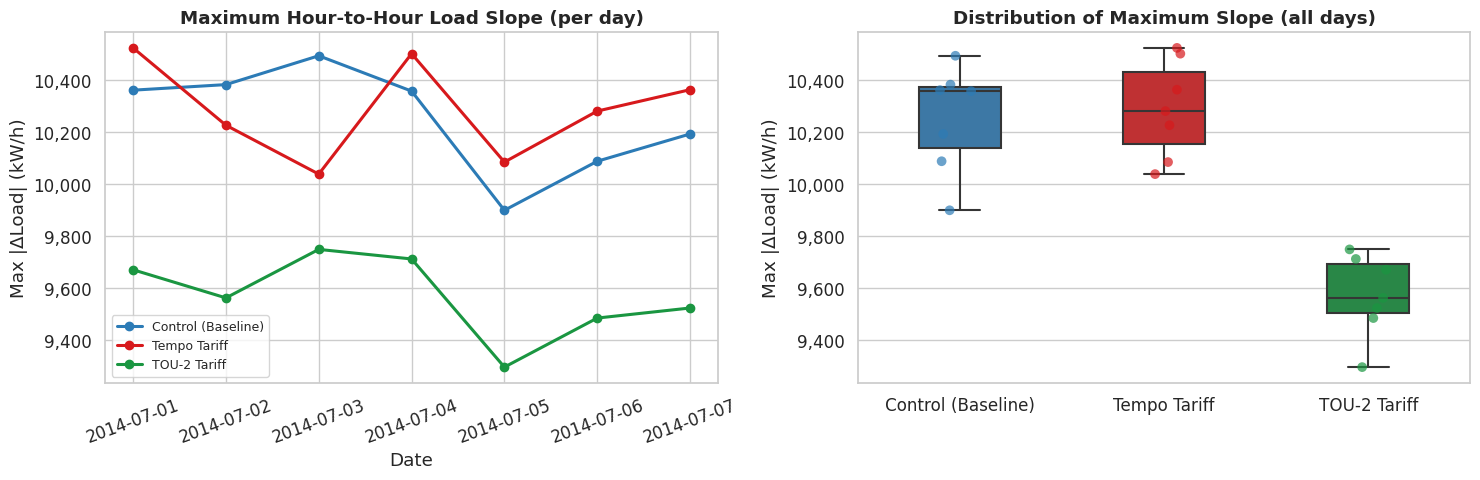

In [17]:
# ── Maximum slope: time series + box plots ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for name in profiles.keys():
    ax.plot(dates, max_slopes[name].values,
            color=POLICY_COLORS[name], lw=2.2, marker="o", ms=6, label=name)
ax.set_title("Maximum Hour-to-Hour Load Slope (per day)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Max |ΔLoad| (kW/h)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax2 = axes[1]
plot_data = max_slopes.melt(var_name="Policy", value_name="Max Slope (kW/h)")
palette   = {p: POLICY_COLORS[p] for p in profiles.keys()}
sns.boxplot(data=plot_data, x="Policy", y="Max Slope (kW/h)",
            palette=palette, width=0.4, linewidth=1.5, ax=ax2)
sns.stripplot(data=plot_data, x="Policy", y="Max Slope (kW/h)",
              palette=palette, size=7, jitter=True, ax=ax2, alpha=0.7)
ax2.set_title("Distribution of Maximum Slope (all days)", fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel("Max |ΔLoad| (kW/h)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("output/fig7_max_slope.png", dpi=150, bbox_inches="tight")
plt.show()

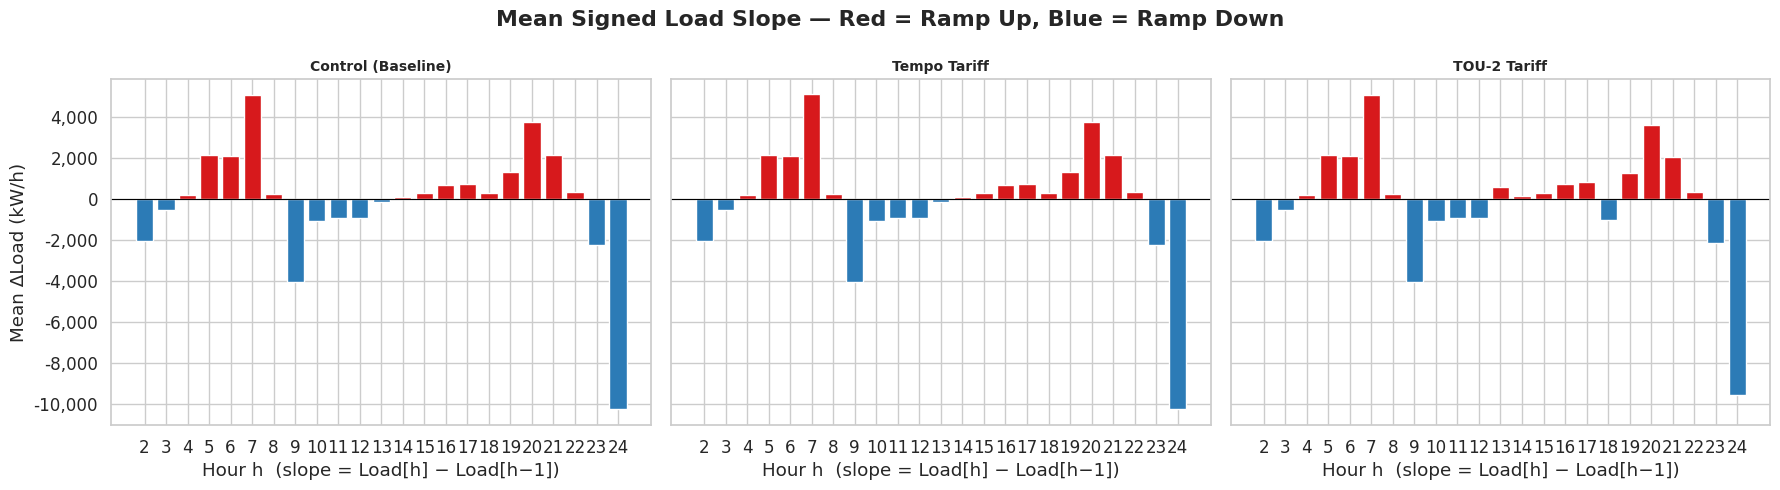

In [18]:
# ── Slope profiles: full ΔLoad per hour per day (averaged), all policies ──────
fig, axes = plt.subplots(1, len(profiles), figsize=(18, 5), sharey=True)

for ax, (name, sl) in zip(axes, sys_loads.items()):
    # Mean signed slope across days
    mean_slope = sl.diff(axis=1).mean(axis=0).values[1:]  # drop NaN at hour 1
    hours = range(2, 25)
    colors = ["#d7191c" if v > 0 else "#2c7bb6" for v in mean_slope]
    ax.bar(hours, mean_slope, color=colors, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.set_xlabel("Hour h  (slope = Load[h] − Load[h−1])")
    ax.set_xticks(range(2, 25))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[0].set_ylabel("Mean ΔLoad (kW/h)")
fig.suptitle("Mean Signed Load Slope — Red = Ramp Up, Blue = Ramp Down",
             fontweight="bold")
plt.tight_layout()
plt.savefig("output/fig8_slope_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

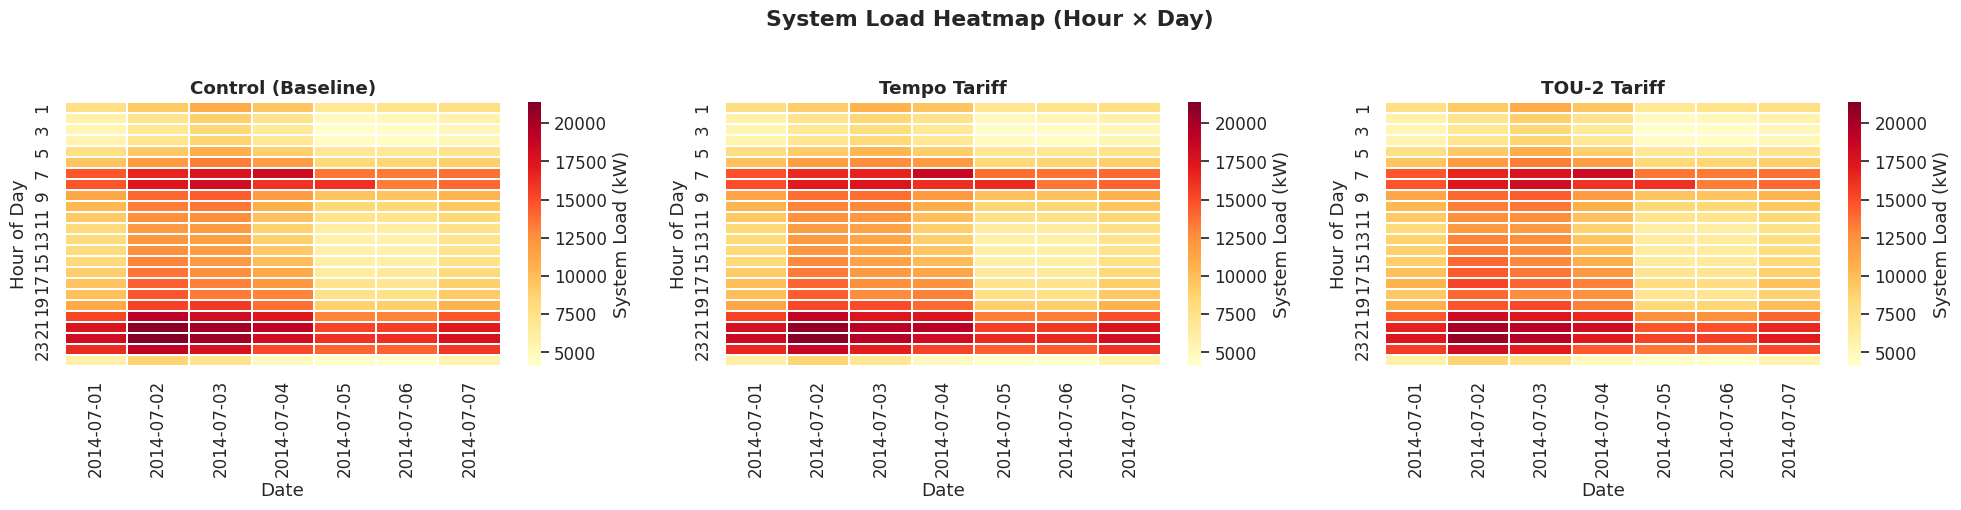

In [19]:
# ── Heatmap: system load by hour × day for each policy ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Consistent color scale across all three policies
all_vals = np.concatenate([sl.values for sl in sys_loads.values()])
vmin, vmax = all_vals.min(), all_vals.max()

for ax, (name, sl) in zip(axes, sys_loads.items()):
    data = sl.T  # rows=hours, cols=days
    data.index = [int(h) for h in data.index]
    sns.heatmap(data, ax=ax, cmap="YlOrRd", vmin=vmin, vmax=vmax,
                annot=False, fmt=".0f", linewidths=0.3,
                cbar_kws={"label": "System Load (kW)"})
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Hour of Day")

fig.suptitle("System Load Heatmap (Hour × Day)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/fig9_load_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Results Summary

All key results consolidated in one place.

In [20]:
print("\n" + "=" * 72)
print("SECTION 1 — COINCIDENT PEAK DEMAND REDUCTION")
print("=" * 72)

print("\n[A] Absolute reduction (kW) — mean & percentiles:")
display(summary_kw.round(2))

print("\n[B] Relative reduction (% of baseline peak) — mean & percentiles:")
display(summary_pct.round(3))

print("\n" + "=" * 72)
print("SECTION 2 — LOAD VARIANCE & MAXIMUM SLOPE")
print("=" * 72)
display(var_summary_df.round(1))

print("\nWithin-day variance detail (kW²):")
display(within_day_var.round(1))

print("\nAcross-day variance detail (kW²):")
display(across_day_var.round(1))

print("\nMaximum slope detail (kW/h):")
display(max_slopes.round(1))

print("\nHour at which maximum slope occurs:")
display(max_slope_hours)


SECTION 1 — COINCIDENT PEAK DEMAND REDUCTION

[A] Absolute reduction (kW) — mean & percentiles:


,Mean,Std,P10,P25,P50,P75,P90
Reduction (kW),,,,,,,
Tempo Tariff,-30.56,460.51,-293.73,-287.89,-274.04,23.76,540.0
TOU-2 Tariff,677.46,289.92,424.21,682.16,756.38,820.41,888.5



[B] Relative reduction (% of baseline peak) — mean & percentiles:


,Mean,Std,P10,P25,P50,P75,P90
Reduction (%),,,,,,,
Tempo Tariff,-0.329,2.373,-1.816,-1.703,-1.506,0.034,2.616
TOU-2 Tariff,3.606,1.473,2.250,3.893,4.253,4.271,4.303



SECTION 2 — LOAD VARIANCE & MAXIMUM SLOPE


...

,Control (Baseline),Tempo Tariff,TOU-2 Tariff
Hour,,,
1,2154935.7,1631476.8,2154935.7
2,2154457.6,1732558.8,2154457.6
3,2218978.3,1817354.1,2218978.3
4,2309562.5,1878310.7,2309562.5
5,2269479.2,1708532.7,2269479.2
6,3925744.2,3113536.4,3925744.2
7,4261934.7,3508192.3,4261934.7
8,3189304.2,2214201.5,3189304.2
9,3750846.9,2825156.3,3750846.9



Maximum slope detail (kW/h):


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
date,,,
2014-07-01,10362.7,10525.6,9671.0
2014-07-02,10384.2,10227.6,9562.6
2014-07-03,10495.3,10039.4,9749.4
2014-07-04,10359.1,10503.3,9712.6
2014-07-05,9900.1,10085.8,9296.0
2014-07-06,10089.0,10282.2,9485.0
2014-07-07,10194.0,10364.6,9523.7



Hour at which maximum slope occurs:


,Control (Baseline),Tempo Tariff,TOU-2 Tariff
date,,,
2014-07-01,24,24,24
2014-07-02,24,24,24
2014-07-03,24,24,24
2014-07-04,24,24,24
2014-07-05,24,24,24
2014-07-06,24,24,24
2014-07-07,24,24,24
